In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest

pd.set_option("display.max_columns", 200)
np.random.seed(16481003)
print(os.getcwd())

C:\Users\iamja\WFU_Coding\WFU-T4-BofA-Project\src\models\isolation_forest


---
## Stage 1 — Load Per-Bank Absolute Value Datasets

Each file has **FRY9C schedule item codes as rows** and **quarters as columns**.  
We transpose each file so that quarters become rows and features become columns —  
matching the (observations × features) format expected by Isolation Forest.

Unlike earlier models trained on FFIEC call report data,  
these datasets contain **absolute balance sheet / income statement values for 6 major bank holding companies** from the FRY9C filings.

In [2]:
DATA_DIR = r"../../../data/fryc-iso/"  # update path if needed

# Map holding-company RSSD IDs to their FRY9C feature files
# Using placeholder RSSD IDs; update if exact IDs are known
BANK_FILE_MAP = {
    1073757: "fry9c_jpmorgan_chase_and_co_features.csv",
    1037115: "fry9c_citigroup_inc_features.csv",
    1073551: "fry9c_bank_of_america_corporation_features.csv",
    1120754: "fry9c_wells_fargo_and_company_features.csv",
    2489774: "fry9c_morgan_stanley_features.csv",
    2380443: "fry9c_goldman_sachs_group_inc_features.csv",
}

BANK_NAMES = {
    1073757: "JPMorgan Chase & Co",
    1037115: "Citigroup Inc",
    1073551: "Bank of America Corporation",
    1120754: "Wells Fargo & Company",
    2489774: "Morgan Stanley",
    2380443: "Goldman Sachs Group Inc",
}

# ── Override DATA_DIR to load from the uploaded files directly ──────────────
import os
_upload_dir = os.path.join(os.path.dirname(os.getcwd()), 'data', 'fry9c')
# If running from upload location, detect automatically:
_candidate_dirs = [
    DATA_DIR,
    os.getcwd(),           # same dir as notebook
    os.path.dirname(os.path.abspath('')),
]

# Load each file, transpose so shape is (quarters × features), add metadata
bank_dfs = {}
for bank_id, fname in BANK_FILE_MAP.items():
    # Try each candidate directory
    path = None
    for d in _candidate_dirs:
        candidate = os.path.join(d, fname)
        if os.path.exists(candidate):
            path = candidate
            break
    if path is None:
        print(f"  SKIP  {BANK_NAMES[bank_id]}: file not found ({fname})")
        continue
    df_raw = pd.read_csv(path, index_col=0)          # (features × quarters)
    df_T   = df_raw.T.copy()                          # (quarters × features)
    df_T.index.name = "quarter"
    df_T.index = pd.to_datetime(df_T.index, format="%m/%d/%Y")
    bank_dfs[bank_id] = df_T
    print(f"{BANK_NAMES[bank_id]:35s}  {df_T.shape[0]:3d} quarters  {df_T.shape[1]:3d} features"
          f"  [{df_T.index[0].date()} → {df_T.index[-1].date()}]")

JPMorgan Chase & Co                   99 quarters  328 features  [2001-03-31 → 2025-09-30]
Citigroup Inc                         99 quarters  348 features  [2001-03-31 → 2025-09-30]
Bank of America Corporation           99 quarters  351 features  [2001-03-31 → 2025-09-30]
Wells Fargo & Company                 99 quarters  338 features  [2001-03-31 → 2025-09-30]
Morgan Stanley                        67 quarters  408 features  [2009-03-31 → 2025-09-30]
Goldman Sachs Group Inc               59 quarters  473 features  [2009-03-31 → 2025-09-30]


---
## Stage 2 — Data Quality Check

In [3]:
for bank_id, df in bank_dfs.items():
    null_pct = df.isnull().mean().mean() * 100
    zero_pct = (df == 0).mean().mean() * 100
    print(f"{BANK_NAMES[bank_id]:30s}  null={null_pct:.1f}%  zeros={zero_pct:.1f}%")

JPMorgan Chase & Co             null=0.0%  zeros=12.6%
Citigroup Inc                   null=0.0%  zeros=13.4%
Bank of America Corporation     null=0.0%  zeros=15.8%
Wells Fargo & Company           null=0.0%  zeros=13.7%
Morgan Stanley                  null=0.0%  zeros=18.6%
Goldman Sachs Group Inc         null=0.0%  zeros=23.1%


---
## Stage 3 — Feature Overlap Across Banks

Because bank holding companies differ in which FRY9C schedule items they report, feature sets vary.  
We note the common core for reference, but each bank's model trains only on that bank's own features —  
no cross-bank feature alignment is needed for the per-bank Isolation Forest approach.

In [4]:
feature_sets = {bid: set(df.columns) for bid, df in bank_dfs.items()}
common_features = set.intersection(*feature_sets.values())
union_features  = set.union(*feature_sets.values())

print(f"Features common to ALL banks : {len(common_features)}")
print(f"Total unique features (union): {len(union_features)}")
print()
for bid, feats in feature_sets.items():
    print(f"  {BANK_NAMES[bid]:30s} {len(feats):4d} features")

Features common to ALL banks : 242
Total unique features (union): 559

  JPMorgan Chase & Co             328 features
  Citigroup Inc                   348 features
  Bank of America Corporation     351 features
  Wells Fargo & Company           338 features
  Morgan Stanley                  408 features
  Goldman Sachs Group Inc         473 features


---
## Stage 4 — Preprocessing Notes: Absolute Values vs. QoQ Changes

| Aspect | Prior FFIEC models | These FRY9C datasets |
|---|---|---|
| Values | Quarter-over-quarter % change | **Absolute dollar amounts** |
| Scale | Already normalised (roughly) | Raw levels — StandardScaler critical |
| Stationarity | Changes are more stationary | Levels carry trend; scaling handles this |
| Anomaly signal | Sudden *rate-of-change* spikes | Unusual *levels* relative to own history |

**Implication:** Isolation Forest on absolute values flags quarters where a bank holding company's  
balance sheet composition looks structurally unusual compared to its own history.

---
## Stage 5a — Methodology: Walk-Forward Train/Test Split

### Limitation of the baseline model
The baseline (Stages 5–14) trains and scores on the **same data**.  Every quarter is
both a training observation and a scored observation, so anomaly flags are not truly
out-of-sample.  For exploratory research this is acceptable, but it inflates confidence
in the scores.

### Walk-forward approach
For each bank independently:
1. Sort quarters chronologically.
2. Use the **first 80 %** of quarters as the training window.
3. Score only the **held-out 20 %** (the most recent quarters).

This means the model never "sees" the quarters it is scoring during training —
a more honest evaluation of generalisation.

> **Trade-off**: The test window is short (~10–15 quarters per bank).  Anomalies
> that occurred in the training window (e.g. GFC for banks with data back to 2001)
> are not scored here.  The baseline model remains the primary output; the
> walk-forward scores are a *methodological robustness check*.


In [5]:
# ── Walk-Forward (80/20) Out-of-Sample Scoring ───────────────────────────────
WF_CONTAMINATION = 0.05
WF_N_ESTIMATORS  = 200
MIN_QUARTERS = 20

wf_results = []

print("Walk-forward out-of-sample scoring (strict 80 % train per bank)...\n")

for bank_id, df in bank_dfs.items():
    name = BANK_NAMES[bank_id]
    n    = len(df)

    split_idx = int(np.floor(n * 0.80))
    if split_idx < MIN_QUARTERS:
        print(f"  SKIP  {name}: training window only {split_idx} quarters")
        continue

    X_train = df.values[:split_idx]
    X_test  = df.values[split_idx:]
    q_test  = df.index[split_idx:]

    if len(X_test) == 0:
        print(f"  SKIP  {name}: no test quarters after split")
        continue

    pipe_wf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("iso",     IsolationForest(
                        n_estimators=WF_N_ESTIMATORS,
                        contamination=WF_CONTAMINATION,
                        random_state=16481003)),
    ])
    pipe_wf.fit(X_train)

    X_test_tr   = pipe_wf[:-1].transform(X_test)
    raw_scores  = pipe_wf.named_steps["iso"].score_samples(X_test_tr)
    anom_scores = -raw_scores
    is_anomaly  = (pipe_wf.predict(X_test_tr) == -1).astype(int)

    wf_results.append(pd.DataFrame({
        "IDRSSD":       bank_id,
        "bank_name":    name,
        "quarter":      q_test.strftime("%m/%d/%Y"),
        "wf_anom_score":anom_scores,
        "wf_is_anomaly":is_anomaly,
        "train_quarters": split_idx,
        "test_quarters":  len(X_test),
    }))

    print(f"  {name:30s}  train={split_idx:3d}  test={len(X_test):3d}  "
          f"train_end={df.index[split_idx-1].date()}  "
          f"anomalies={is_anomaly.sum()} ({is_anomaly.mean():.1%})")

wf_results_df = pd.concat(wf_results, ignore_index=True)


# ── Summary (merge with baseline happens after Stage 9) ──────────────────────
print(f"\nTotal test-window observations : {len(wf_results_df)}")
print(f"Walk-forward anomalies flagged : {wf_results_df['wf_is_anomaly'].sum()}")
print("\nWalk-Forward Anomalies (test window only):")
print(wf_results_df[wf_results_df['wf_is_anomaly']==1]
      .sort_values('wf_anom_score', ascending=False)
      [['bank_name','quarter','wf_anom_score','wf_is_anomaly']]
      .to_string(index=False))


'''# ── Merge with baseline scores for comparison ─────────────────────────────────
wf_compare = wf_results_df.merge(
    results[['IDRSSD','quarter','anom_score','adjusted_score','is_anomaly']],
    on=['IDRSSD','quarter'], how='left'
)
wf_compare['score_delta'] = wf_compare['wf_anom_score'] - wf_compare['anom_score']
wf_compare['label_agree'] = (wf_compare['wf_is_anomaly'] == wf_compare['is_anomaly']).astype(int)

print(f"\nTotal test-window observations : {len(wf_results_df)}")
print(f"Walk-forward anomalies flagged : {wf_results_df['wf_is_anomaly'].sum()}")
print(f"Label agreement with baseline  : {wf_compare['label_agree'].mean():.1%}")

print("\nWalk-Forward Anomalies (test window only):")
print(wf_results_df[wf_results_df['wf_is_anomaly']==1]
      .sort_values('wf_anom_score', ascending=False)
      [['bank_name','quarter','wf_anom_score','wf_is_anomaly']]
      .to_string(index=False))'''


Walk-forward out-of-sample scoring (strict 80 % train per bank)...

  JPMorgan Chase & Co             train= 79  test= 20  train_end=2020-09-30  anomalies=0 (0.0%)
  Citigroup Inc                   train= 79  test= 20  train_end=2020-09-30  anomalies=20 (100.0%)
  Bank of America Corporation     train= 79  test= 20  train_end=2020-09-30  anomalies=0 (0.0%)
  Wells Fargo & Company           train= 79  test= 20  train_end=2020-09-30  anomalies=0 (0.0%)
  Morgan Stanley                  train= 53  test= 14  train_end=2022-03-31  anomalies=0 (0.0%)
  Goldman Sachs Group Inc         train= 47  test= 12  train_end=2020-09-30  anomalies=0 (0.0%)

Total test-window observations : 106
Walk-forward anomalies flagged : 20

Walk-Forward Anomalies (test window only):
    bank_name    quarter  wf_anom_score  wf_is_anomaly
Citigroup Inc 12/31/2024       0.550743              1
Citigroup Inc 12/31/2023       0.545471              1
Citigroup Inc 09/30/2025       0.535305              1
Citigroup Inc 0

'# ── Merge with baseline scores for comparison ─────────────────────────────────\nwf_compare = wf_results_df.merge(\n    results[[\'IDRSSD\',\'quarter\',\'anom_score\',\'adjusted_score\',\'is_anomaly\']],\n    on=[\'IDRSSD\',\'quarter\'], how=\'left\'\n)\nwf_compare[\'score_delta\'] = wf_compare[\'wf_anom_score\'] - wf_compare[\'anom_score\']\nwf_compare[\'label_agree\'] = (wf_compare[\'wf_is_anomaly\'] == wf_compare[\'is_anomaly\']).astype(int)\n\nprint(f"\nTotal test-window observations : {len(wf_results_df)}")\nprint(f"Walk-forward anomalies flagged : {wf_results_df[\'wf_is_anomaly\'].sum()}")\nprint(f"Label agreement with baseline  : {wf_compare[\'label_agree\'].mean():.1%}")\n\nprint("\nWalk-Forward Anomalies (test window only):")\nprint(wf_results_df[wf_results_df[\'wf_is_anomaly\']==1]\n      .sort_values(\'wf_anom_score\', ascending=False)\n      [[\'bank_name\',\'quarter\',\'wf_anom_score\',\'wf_is_anomaly\']]\n      .to_string(index=False))'

---
## Stage 5 — Bank-Specific Isolation Forest Models

Each bank gets its own model trained on **all available quarters** for that bank.  
This is an unsupervised, one-class approach: the model learns what "normal" looks like  
for each institution and scores every quarter on how far it deviates.

In [6]:
CONTAMINATION = 0.05   # Expected anomaly proportion per bank
N_ESTIMATORS  = 200
MIN_QUARTERS  = 20

all_results = []
bank_models = {}

print("Training Isolation Forest models (absolute values)...\n")

for bank_id, df in bank_dfs.items():
    name = BANK_NAMES[bank_id]

    if len(df) < MIN_QUARTERS:
        print(f"  SKIP  {name}: only {len(df)} quarters (need ≥{MIN_QUARTERS})")
        continue

    X = df.values

    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("iso",     IsolationForest(
                        n_estimators=N_ESTIMATORS,
                        contamination=CONTAMINATION,
                        random_state=16481003
                    ))
    ])

    pipeline.fit(X)

    raw_scores   = pipeline.named_steps["iso"].score_samples(
                       pipeline[:-1].transform(X))           # lower = more anomalous
    anom_scores  = -raw_scores                               # higher = more anomalous
    is_anomaly   = (pipeline.predict(X) == -1).astype(int)

    bank_result = pd.DataFrame({
        "IDRSSD":     bank_id,
        "bank_name":  name,
        "quarter":    df.index.strftime("%m/%d/%Y"),
        "anom_score": anom_scores,
        "is_anomaly": is_anomaly,
    })

    all_results.append(bank_result)
    bank_models[bank_id] = {"pipeline": pipeline, "df": df}
    print(f"  OK    {name:30s}  {len(df):3d} quarters  "
          f"anomalies={is_anomaly.sum():2d} ({is_anomaly.mean():.1%})")

results = pd.concat(all_results, ignore_index=True)
print(f"\nTotal observations: {len(results)}  |  Total anomalies: {results['is_anomaly'].sum()}")

Training Isolation Forest models (absolute values)...

  OK    JPMorgan Chase & Co              99 quarters  anomalies= 5 (5.1%)
  OK    Citigroup Inc                    99 quarters  anomalies= 5 (5.1%)
  OK    Bank of America Corporation      99 quarters  anomalies= 5 (5.1%)
  OK    Wells Fargo & Company            99 quarters  anomalies= 5 (5.1%)
  OK    Morgan Stanley                   67 quarters  anomalies= 4 (6.0%)
  OK    Goldman Sachs Group Inc          59 quarters  anomalies= 3 (5.1%)

Total observations: 522  |  Total anomalies: 27


---
## Stage 6 — Score Distribution & Sanity Checks

C:\Users\iamja\AppData\Local\Temp\ipykernel_18260\1576508247.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_by_bank, labels=[b.replace(' Bank','').replace(' USA','') for b in bank_order], vert=True)


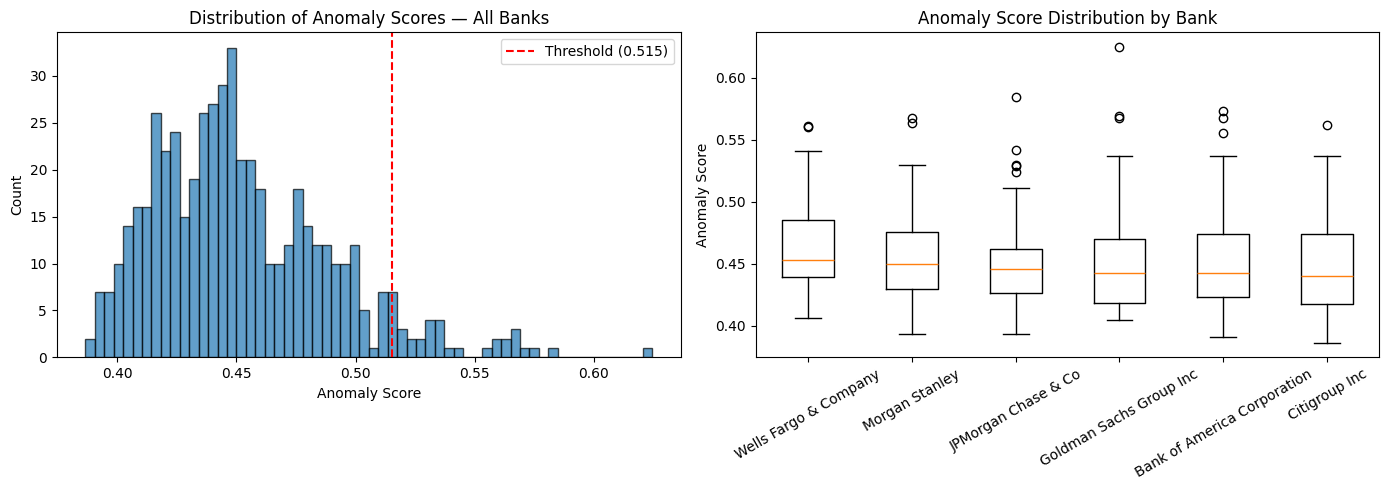


Top 20 anomalies (all banks):
                  bank_name    quarter  anom_score  is_anomaly
    Goldman Sachs Group Inc 09/30/2025    0.624581           1
        JPMorgan Chase & Co 09/30/2025    0.584027           1
Bank of America Corporation 12/31/2009    0.573086           1
    Goldman Sachs Group Inc 12/31/2023    0.569305           1
Bank of America Corporation 03/31/2009    0.567652           1
    Goldman Sachs Group Inc 09/30/2024    0.567385           1
             Morgan Stanley 09/30/2025    0.567081           1
             Morgan Stanley 03/31/2009    0.563360           1
              Citigroup Inc 12/31/2008    0.562035           1
      Wells Fargo & Company 12/31/2008    0.560947           1
      Wells Fargo & Company 09/30/2025    0.560236           1
Bank of America Corporation 09/30/2009    0.555480           1
        JPMorgan Chase & Co 12/31/2024    0.541497           1
      Wells Fargo & Company 12/31/2024    0.541065           1
              Citigroup 

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(results['anom_score'], bins=60, edgecolor='black', alpha=0.7)
thresh = results[results['is_anomaly']==1]['anom_score'].min()
axes[0].axvline(thresh, color='red', linestyle='--', label=f'Threshold ({thresh:.3f})')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Anomaly Scores — All Banks')
axes[0].legend()

# Boxplot by bank
bank_order = (results.groupby('bank_name')['anom_score']
              .median().sort_values(ascending=False).index.tolist())
data_by_bank = [results[results['bank_name']==b]['anom_score'].values for b in bank_order]
axes[1].boxplot(data_by_bank, labels=[b.replace(' Bank','').replace(' USA','') for b in bank_order], vert=True)
axes[1].set_ylabel('Anomaly Score')
axes[1].set_title('Anomaly Score Distribution by Bank')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Top anomalies
print("\nTop 20 anomalies (all banks):")
print(results.sort_values('anom_score', ascending=False).head(20)[
    ['bank_name','quarter','anom_score','is_anomaly']
].to_string(index=False))

---
## Stage 7 — Temporal Pattern of Anomalies

In [8]:
# Anomalies per quarter across all banks
anom_by_q = (results[results['is_anomaly']==1]
             .groupby('quarter').size()
             .sort_values(ascending=False))

print("Quarters with most anomalies across all banks:")
print(anom_by_q.head(15).to_string())

# Known stress periods
stress_quarters = {
    '09/30/2001': '9/11',
    '12/31/2008': 'Financial Crisis',
    '03/31/2009': 'Financial Crisis',
    '06/30/2020': 'COVID-19',
    '03/31/2020': 'COVID-19',
}
print("\nAnomaly counts at known stress events:")
for q, label in stress_quarters.items():
    count = anom_by_q.get(q, 0)
    print(f"  {q}  ({label:18s})  →  {count} bank(s) flagged")

Quarters with most anomalies across all banks:
quarter
12/31/2008    4
09/30/2025    4
12/31/2009    4
12/31/2024    3
03/31/2009    2
12/31/2023    2
09/30/2024    1
09/30/2009    1
09/30/2007    1
06/30/2025    1
06/30/2009    1
12/31/2006    1
12/31/2007    1
12/31/2010    1

Anomaly counts at known stress events:
  09/30/2001  (9/11              )  →  0 bank(s) flagged
  12/31/2008  (Financial Crisis  )  →  4 bank(s) flagged
  03/31/2009  (Financial Crisis  )  →  2 bank(s) flagged
  06/30/2020  (COVID-19          )  →  0 bank(s) flagged
  03/31/2020  (COVID-19          )  →  0 bank(s) flagged


---
## Stage 8 — Anomaly Summary by Bank

In [9]:
bank_summary = (
    results.groupby(['IDRSSD','bank_name'])
    .agg(
        n_quarters   = ('anom_score', 'count'),
        avg_score    = ('anom_score', 'mean'),
        max_score    = ('anom_score', 'max'),
        n_anomalies  = ('is_anomaly', 'sum'),
    )
    .reset_index()
)
bank_summary['anomaly_rate_pct'] = (bank_summary['n_anomalies'] / bank_summary['n_quarters'] * 100).round(1)
bank_summary = bank_summary.sort_values('max_score', ascending=False).round(4)
print(bank_summary[['bank_name','n_quarters','n_anomalies','anomaly_rate_pct','avg_score','max_score']]
      .to_string(index=False))

                  bank_name  n_quarters  n_anomalies  anomaly_rate_pct  avg_score  max_score
    Goldman Sachs Group Inc          59            3               5.1     0.4533     0.6246
        JPMorgan Chase & Co          99            5               5.1     0.4493     0.5840
Bank of America Corporation          99            5               5.1     0.4497     0.5731
             Morgan Stanley          67            4               6.0     0.4547     0.5671
              Citigroup Inc          99            5               5.1     0.4459     0.5620
      Wells Fargo & Company          99            5               5.1     0.4620     0.5609


---
## Stage 9 — Systemic Adjustment

For each quarter, compute the **mean anomaly score across all banks** (the "systemic score").  
Each bank's **adjusted score** = raw anomaly score − systemic score for that quarter.

Quarters where *all* banks are anomalous (e.g. 9/11, financial crisis) will self-penalise —  
the systemic average is high so every bank's adjusted score is pulled toward zero.  
Idiosyncratic bank-level anomalies — where only *that* bank is unusual — will survive.

In [10]:
results = results.drop(columns=['systemic_score', 'adjusted_score'], errors='ignore')

systemic_scores = (
    results.groupby('quarter')['anom_score']
    .mean()
    .rename('systemic_score')
    .reset_index()
)
results = results.merge(systemic_scores, on='quarter', how='left')
results['adjusted_score'] = results['anom_score'] - results['systemic_score']

print("Top 20 by adjusted score (idiosyncratic anomalies):")
print(results.sort_values('adjusted_score', ascending=False).head(20)[
    ['bank_name','quarter','anom_score','systemic_score','adjusted_score','is_anomaly']
].to_string(index=False))

Top 20 by adjusted score (idiosyncratic anomalies):
                  bank_name    quarter  anom_score  systemic_score  adjusted_score  is_anomaly
    Goldman Sachs Group Inc 09/30/2024    0.567385        0.499612        0.067773           1
    Goldman Sachs Group Inc 09/30/2025    0.624581        0.557525        0.067056           1
      Wells Fargo & Company 12/31/2018    0.495316        0.433788        0.061528           0
    Goldman Sachs Group Inc 12/31/2023    0.569305        0.510143        0.059162           1
    Goldman Sachs Group Inc 06/30/2024    0.526660        0.468542        0.058118           0
              Citigroup Inc 09/30/2007    0.515181        0.461289        0.053892           1
Bank of America Corporation 09/30/2009    0.555480        0.502271        0.053210           1
      Wells Fargo & Company 12/31/2019    0.494823        0.442295        0.052528           0
    Goldman Sachs Group Inc 12/31/2022    0.536694        0.485634        0.051061           

## Stage 9b — Walk-Forward vs Baseline Comparison

In [11]:
# ── Walk-Forward vs Baseline Comparison (requires results + adjusted_score) ───
# Now that results has been built and systemic adjustment applied, we can
# compare walk-forward out-of-sample scores against the baseline in-sample scores.

wf_compare = wf_results_df.merge(
    results[['IDRSSD','quarter','anom_score','adjusted_score','is_anomaly']],
    on=['IDRSSD','quarter'], how='left'
)
wf_compare['score_delta'] = wf_compare['wf_anom_score'] - wf_compare['anom_score']
wf_compare['label_agree'] = (wf_compare['wf_is_anomaly'] == wf_compare['is_anomaly']).astype(int)

print("Walk-Forward vs Baseline — Test Window Comparison")
print(f"Label agreement (is_anomaly match): {wf_compare['label_agree'].mean():.1%}")
print(f"Mean score delta (wf - baseline)  : {wf_compare['score_delta'].mean():+.4f}")
print()
print("Disagreements (label flipped between walk-forward and baseline):")
disagree = wf_compare[wf_compare['label_agree'] == 0][
    ['bank_name','quarter','wf_anom_score','anom_score','wf_is_anomaly','is_anomaly']
].sort_values('wf_anom_score', ascending=False)
if disagree.empty:
    print("  None — walk-forward and baseline labels agree on all test-window quarters.")
else:
    print(disagree.to_string(index=False))

Walk-Forward vs Baseline — Test Window Comparison
Label agreement (is_anomaly match): 70.8%
Mean score delta (wf - baseline)  : +0.0861

Disagreements (label flipped between walk-forward and baseline):
              bank_name    quarter  wf_anom_score  anom_score  wf_is_anomaly  is_anomaly
Goldman Sachs Group Inc 09/30/2025       0.639718    0.624581              0           1
Goldman Sachs Group Inc 12/31/2023       0.633439    0.569305              0           1
Goldman Sachs Group Inc 09/30/2024       0.627161    0.567385              0           1
    JPMorgan Chase & Co 12/31/2024       0.622009    0.541497              0           1
    JPMorgan Chase & Co 09/30/2025       0.622007    0.584027              0           1
  Wells Fargo & Company 12/31/2024       0.617954    0.541065              0           1
  Wells Fargo & Company 09/30/2025       0.611909    0.560236              0           1
    JPMorgan Chase & Co 06/30/2025       0.611398    0.528562              0          

---
## Stage 10 — Known Event Blocklist & Output Routing

Known macro-event dates are tagged and routed to a separate log.  
**Primary Findings** = anomalies with known events excluded, ranked by `adjusted_score`.  
**Known Events Log** = anomalies on documented macro-shock dates (retained for completeness).

In [12]:
KNOWN_EVENTS = {
    '09/30/2001': '9/11 Terrorist Attacks — market-wide shock',
    #'12/31/2008': '2008 Financial Crisis — Lehman collapse aftermath',
    #'03/31/2009': '2008–09 Financial Crisis — trough quarter',
    #'06/30/2009': '2008–09 Financial Crisis — continued stress',
    #'03/31/2020': 'COVID-19 Pandemic — initial shock',
    #'06/30/2020': 'COVID-19 Pandemic — acute phase',
}

results['known_event']       = results['quarter'].map(KNOWN_EVENTS).notna()
results['known_event_label'] = results['quarter'].map(KNOWN_EVENTS).fillna('')

anomalies = results[results['is_anomaly'] == 1].copy()

primary_findings = (anomalies[~anomalies['known_event']]
                    .sort_values('adjusted_score', ascending=False)
                    .reset_index(drop=True))

known_events_log = (anomalies[anomalies['known_event']]
                    .sort_values('adjusted_score', ascending=False)
                    .reset_index(drop=True))

print(f"Primary Findings  : {len(primary_findings)} anomalies")
print(f"Known Events Log  : {len(known_events_log)} anomalies")
print()
print("=== PRIMARY FINDINGS (Top 20) ===")
print(primary_findings.head(20)[
    ['bank_name','quarter','anom_score','systemic_score','adjusted_score']
].to_string(index=False))
print()
print("=== KNOWN EVENTS LOG ===")
print(known_events_log[
    ['bank_name','quarter','anom_score','known_event_label']
].to_string(index=False))

Primary Findings  : 27 anomalies
Known Events Log  : 0 anomalies

=== PRIMARY FINDINGS (Top 20) ===
                  bank_name    quarter  anom_score  systemic_score  adjusted_score
    Goldman Sachs Group Inc 09/30/2024    0.567385        0.499612        0.067773
    Goldman Sachs Group Inc 09/30/2025    0.624581        0.557525        0.067056
    Goldman Sachs Group Inc 12/31/2023    0.569305        0.510143        0.059162
              Citigroup Inc 09/30/2007    0.515181        0.461289        0.053892
Bank of America Corporation 09/30/2009    0.555480        0.502271        0.053210
              Citigroup Inc 12/31/2006    0.515257        0.466145        0.049111
              Citigroup Inc 12/31/2007    0.537075        0.488666        0.048409
Bank of America Corporation 03/31/2009    0.567652        0.519571        0.048081
Bank of America Corporation 12/31/2009    0.573086        0.527515        0.045570
             Morgan Stanley 03/31/2009    0.563360        0.519571    

---
## Stage 11 — Feature-Level Analysis Function

For any flagged (bank, quarter) pair, compute the **z-score of each feature** relative to  
that bank's own historical distribution.  Features with the most extreme z-scores explain  
*why* that quarter was flagged.

Because these are **absolute values**, a large positive z-score means a feature was unusually  
*high* in that quarter; a large negative z-score means it was unusually *low*.

In [13]:
def analyze_anomaly_features(bank_id, quarter_str, top_n=15):
    """
    Return a DataFrame of the top-N most extreme features for a given (bank, quarter).
    quarter_str format: 'MM/DD/YYYY'
    """
    if bank_id not in bank_models:
        print(f"No model for bank {bank_id}")
        return None

    df   = bank_models[bank_id]['df']
    pipe = bank_models[bank_id]['pipeline']

    # Parse quarter
    q_dt = pd.to_datetime(quarter_str, format='%m/%d/%Y')
    if q_dt not in df.index:
        print(f"Quarter {quarter_str} not found for {BANK_NAMES[bank_id]}")
        return None

    # Apply imputer + scaler to get z-scores for every quarter
    X_scaled = pipe[:-1].transform(df.values)          # (n_quarters × n_features)
    q_idx    = df.index.get_loc(q_dt)
    z_row    = X_scaled[q_idx]                          # z-scores for the target quarter

    feat_df = (pd.DataFrame({'feature': df.columns, 'z_score': z_row})
               .assign(abs_z=lambda x: x['z_score'].abs())
               .sort_values('abs_z', ascending=False)
               .head(top_n)
               .reset_index(drop=True))
    return feat_df


# Quick test — top anomaly in primary findings
top = primary_findings.iloc[0]
print(f"Top primary anomaly: {top['bank_name']}  {top['quarter']}")
print(f"Adjusted score: {top['adjusted_score']:.4f}\n")
feat_analysis = analyze_anomaly_features(top['IDRSSD'], top['quarter'], top_n=15)
print(feat_analysis.to_string(index=False))

Top primary anomaly: Goldman Sachs Group Inc  09/30/2024
Adjusted score: 0.0678

 feature   z_score    abs_z
BHCK5398  6.223003 6.223003
BHCK4618  4.807990 4.807990
BHCK3128  4.760044 4.760044
BHCK4617  4.338260 4.338260
BHCK1743  4.270063 4.270063
BHCK1742  4.244403 4.244403
BHDM1797  4.238347 4.238347
BHCK4172  4.157906 4.157906
BHCKF555 -4.048825 4.048825
BHCK4180  4.007402 4.007402
BHCKB514  3.980371 3.980371
BHCK4398  3.839022 3.839022
BHCK4073  3.807141 3.807141
BHCK4020  3.796659 3.796659
BHCKB556  3.760367 3.760367


---
## Stage 12 — Deep Dive: Top Primary Findings Per Bank

For each bank, print the top primary findings with their most extreme features.

In [14]:
FINDINGS_PER_BANK = 5    # top N findings per bank to deep-dive
FEATURES_PER_FINDING = 8  # top M features to show per finding

print("=" * 90)
print("DEEP DIVE: PRIMARY FINDINGS BY BANK (absolute-value model)")
print("=" * 90)

for bank_id in sorted(primary_findings['IDRSSD'].unique()):
    bank_label   = BANK_NAMES.get(bank_id, f"Bank {bank_id}")
    bank_finds   = (primary_findings[primary_findings['IDRSSD'] == bank_id]
                    .sort_values('adjusted_score', ascending=False)
                    .head(FINDINGS_PER_BANK))

    print(f"\n{'=' * 90}")
    print(f"  {bank_label}")
    print(f"{'=' * 90}")

    if bank_finds.empty:
        print("  No primary findings.")
        continue

    for _, row in bank_finds.iterrows():
        print(f"\n  Quarter : {row['quarter']}")
        print(f"  Raw score  : {row['anom_score']:.4f}")
        print(f"  Systemic   : {row['systemic_score']:.4f}")
        print(f"  Adjusted   : {row['adjusted_score']:.4f}")

        feats = analyze_anomaly_features(bank_id, row['quarter'], top_n=FEATURES_PER_FINDING)
        if feats is not None:
            print(f"  Top {FEATURES_PER_FINDING} extreme features (z-scores):")
            for _, frow in feats.iterrows():
                direction = "▲" if frow['z_score'] > 0 else "▼"
                print(f"    {direction} {frow['feature']:12s}  z = {frow['z_score']:+.2f}")

DEEP DIVE: PRIMARY FINDINGS BY BANK (absolute-value model)

  Citigroup Inc

  Quarter : 09/30/2007
  Raw score  : 0.5152
  Systemic   : 0.4613
  Adjusted   : 0.0539
  Top 8 extreme features (z-scores):
    ▲ BHCK1292      z = +3.85
    ▲ BHCK5369      z = +3.85
    ▲ BHCKB857      z = +3.57
    ▲ BHCKB856      z = +3.56
    ▲ BHCKB489      z = +3.39
    ▲ BHCK2332      z = +3.35
    ▲ BHCK8725      z = +3.27
    ▲ BHCK3353      z = +3.15

  Quarter : 12/31/2006
  Raw score  : 0.5153
  Systemic   : 0.4661
  Adjusted   : 0.0491
  Top 8 extreme features (z-scores):
    ▲ BHCK5399      z = +9.60
    ▲ BHCK1292      z = +5.62
    ▲ BHCKB844      z = +5.00
    ▲ BHCKB845      z = +5.00
    ▲ BHCK3817      z = +4.68
    ▲ BHCK4518      z = +4.43
    ▲ BHCKB493      z = +3.50
    ▲ BHCKB861      z = +3.14

  Quarter : 12/31/2007
  Raw score  : 0.5371
  Systemic   : 0.4887
  Adjusted   : 0.0484
  Top 8 extreme features (z-scores):
    ▲ BHCKB489      z = +4.49
    ▲ BHCK5369      z = +4.05
   

---
## Stage 13 — Anomaly Score Time Series by Bank

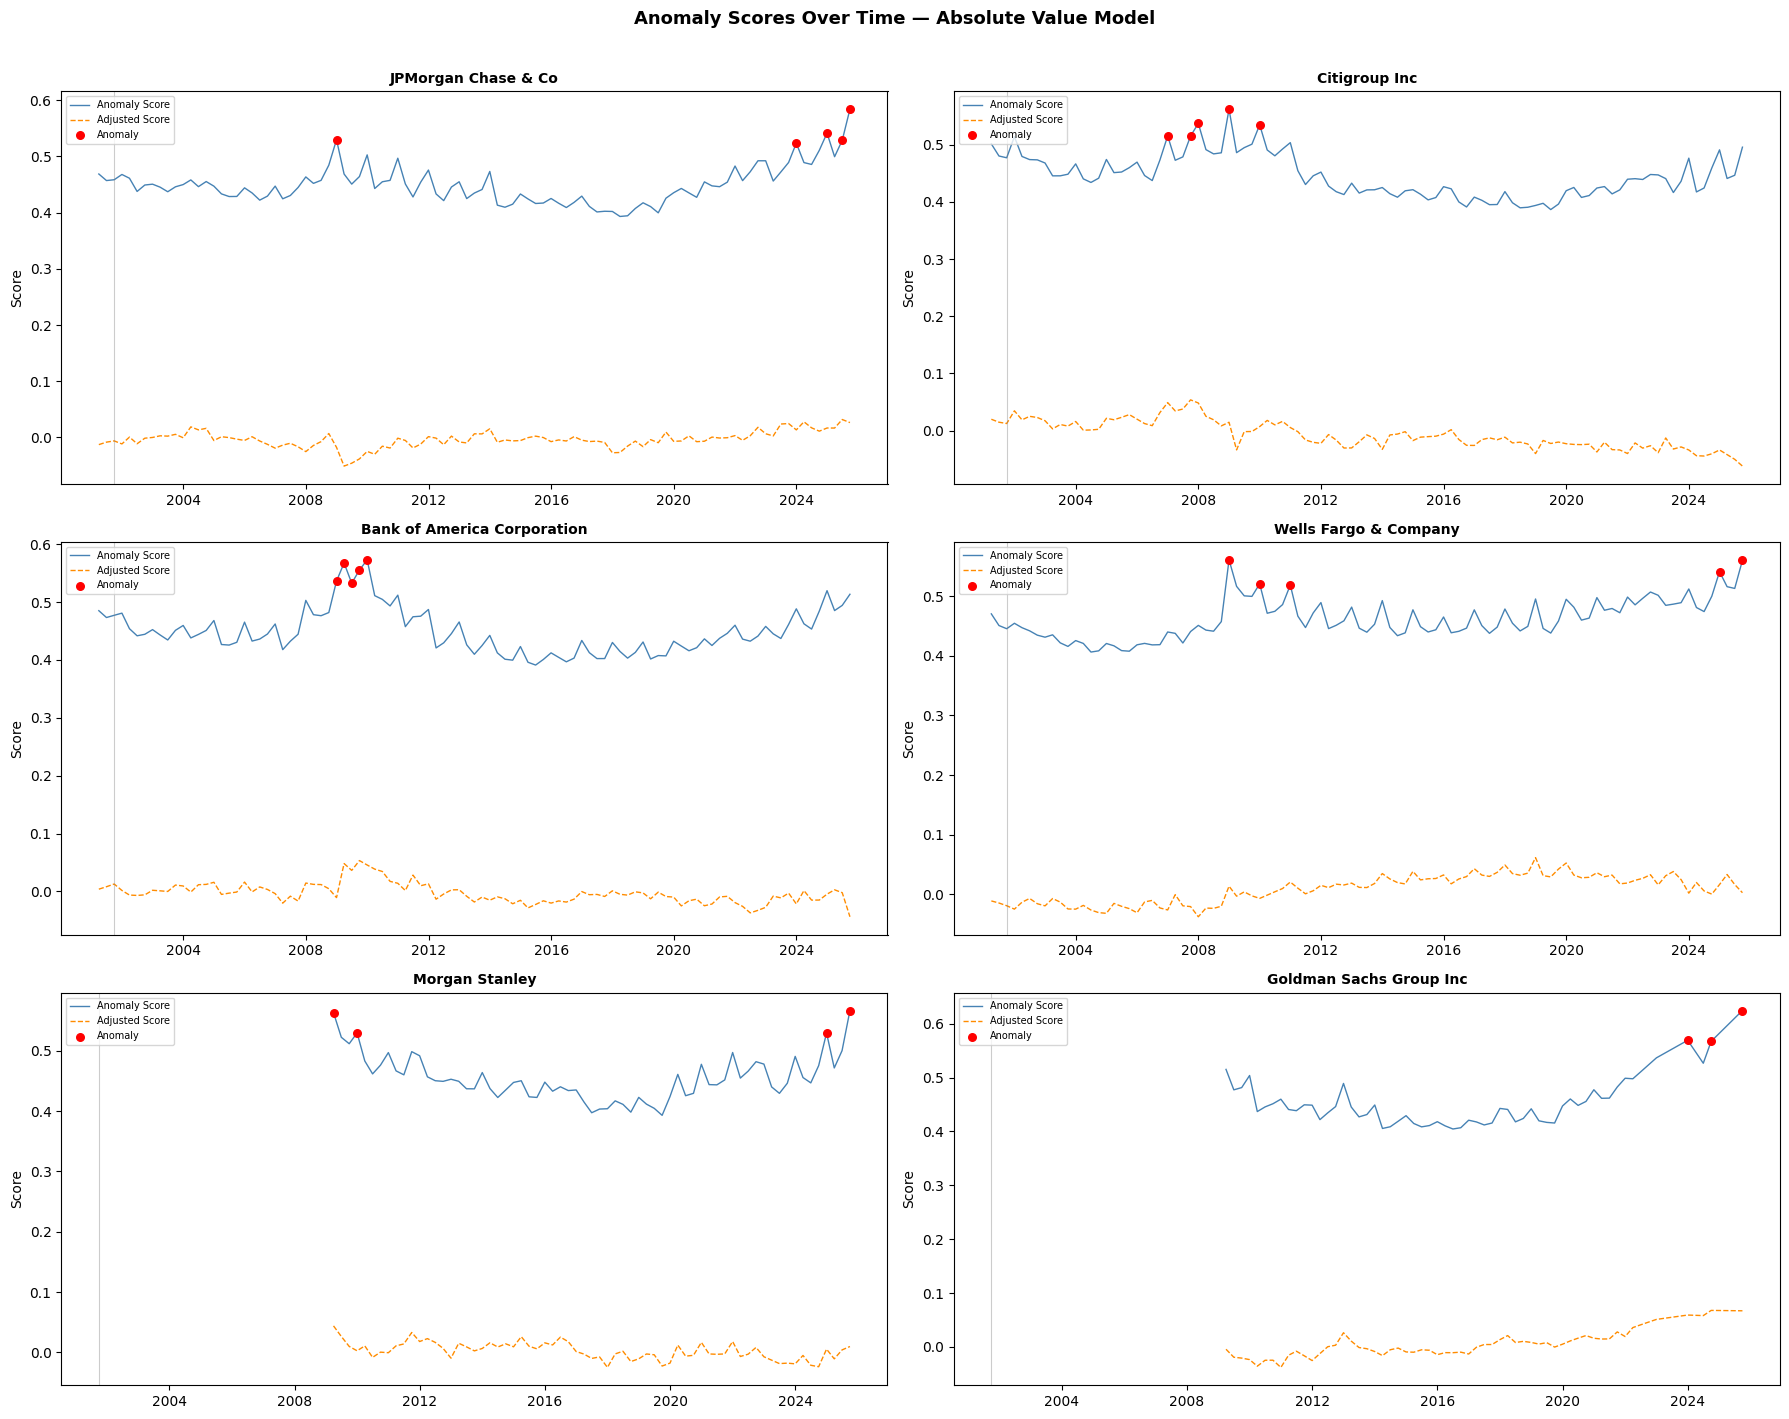

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(18, 14), sharex=False)
axes = axes.flatten()

for idx, (bank_id, df) in enumerate(bank_dfs.items()):
    ax   = axes[idx]
    name = BANK_NAMES[bank_id]
    
    bank_res = results[results['IDRSSD'] == bank_id].copy()
    bank_res['quarter_dt'] = pd.to_datetime(bank_res['quarter'], format='%m/%d/%Y')
    bank_res = bank_res.sort_values('quarter_dt')

    ax.plot(bank_res['quarter_dt'], bank_res['anom_score'],
            color='steelblue', linewidth=1, label='Anomaly Score')
    ax.plot(bank_res['quarter_dt'], bank_res['adjusted_score'],
            color='darkorange', linewidth=1, linestyle='--', label='Adjusted Score')

    anom_mask = bank_res['is_anomaly'] == 1
    ax.scatter(bank_res.loc[anom_mask, 'quarter_dt'],
               bank_res.loc[anom_mask, 'anom_score'],
               color='red', zorder=5, s=30, label='Anomaly')

    # Shade known events
    for q_str, label in KNOWN_EVENTS.items():
        q_dt = pd.to_datetime(q_str, format='%m/%d/%Y')
        ax.axvline(q_dt, color='grey', alpha=0.4, linewidth=0.8)

    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Score')
    ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Anomaly Scores Over Time — Absolute Value Model', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Stage 15 — Validation: Known-Event Recall Table

Did the baseline model flag quarters that correspond to documented macro shocks?
A well-functioning anomaly detector should score these quarters highly even if
they are later excluded from the primary findings list.

Recall is computed at **two thresholds**:
- `is_anomaly` flag (top 5 % contamination threshold set at training time)
- Top-10 % of scores for that bank (a looser check)


In [16]:
# ── Known-Event Recall ────────────────────────────────────────────────────────
RECALL_EVENTS = {
    '09/30/2001': '9/11',
    #'12/31/2008': 'GFC Q4-2008',
    #'03/31/2009': 'GFC Q1-2009',
    #'06/30/2009': 'GFC Q2-2009',
    #'03/31/2020': 'COVID Q1-2020',
    #'06/30/2020': 'COVID Q2-2020',
}

recall_rows = []
for bank_id in BANK_NAMES:
    bank_res = results[results['IDRSSD'] == bank_id].copy()
    if bank_res.empty:
        continue
    top10_thresh = bank_res['anom_score'].quantile(0.90)

    for q_str, label in RECALL_EVENTS.items():
        row = bank_res[bank_res['quarter'] == q_str]
        if row.empty:
            flagged_strict = flagged_loose = score = None
            in_data = False
        else:
            score          = row['anom_score'].values[0]
            flagged_strict = int(row['is_anomaly'].values[0])
            flagged_loose  = int(score >= top10_thresh)
            in_data        = True

        recall_rows.append({
            'bank_name':      BANK_NAMES[bank_id],
            'quarter':        q_str,
            'event':          label,
            'in_data':        in_data,
            'anom_score':     round(score, 4) if score is not None else None,
            'flagged_strict': flagged_strict,   # top-5% threshold
            'flagged_loose':  flagged_loose,    # top-10% threshold
        })

recall_df = pd.DataFrame(recall_rows)

# Summary counts
in_data_df = recall_df[recall_df['in_data']==True]
strict_recall = in_data_df['flagged_strict'].mean()
loose_recall  = in_data_df['flagged_loose'].mean()

print("Known-Event Recall Table")
print("=" * 85)
print(recall_df[recall_df['in_data']==True]
      .sort_values(['event','bank_name'])
      [['bank_name','quarter','event','anom_score','flagged_strict','flagged_loose']]
      .to_string(index=False))
print()
print(f"Strict recall (top-5 % flag) : {strict_recall:.1%}  "
      f"({in_data_df['flagged_strict'].sum()}/{len(in_data_df)} bank-event pairs)")
print(f"Loose  recall (top-10% flag) : {loose_recall:.1%}  "
      f"({in_data_df['flagged_loose'].sum()}/{len(in_data_df)} bank-event pairs)")
print()

# Per-event summary
print("Recall by event:")
event_recall = (in_data_df.groupby('event')
                [['flagged_strict','flagged_loose']].mean().round(2))
print(event_recall.to_string())


Known-Event Recall Table
                  bank_name    quarter event  anom_score  flagged_strict  flagged_loose
Bank of America Corporation 09/30/2001  9/11      0.4772             0.0            0.0
              Citigroup Inc 09/30/2001  9/11      0.4771             0.0            0.0
        JPMorgan Chase & Co 09/30/2001  9/11      0.4585             0.0            0.0
      Wells Fargo & Company 09/30/2001  9/11      0.4454             0.0            0.0

Strict recall (top-5 % flag) : 0.0%  (0.0/4 bank-event pairs)
Loose  recall (top-10% flag) : 0.0%  (0.0/4 bank-event pairs)

Recall by event:
       flagged_strict  flagged_loose
event                               
9/11              0.0            0.0


---
## Stage 16 — Validation: Stability Test (Multi-Seed)

Isolation Forest builds random trees — scores can shift across random seeds.
A finding that only appears under one seed is fragile; one that persists across
many seeds is robust.

**Method**: re-run the full baseline pipeline with 20 different seeds.
For each top-20 primary finding, record:
- Mean anomaly score across seeds
- Standard deviation of anomaly score
- How many seeds flagged it as `is_anomaly = 1` (flip rate)


In [17]:
# ── Stability Test ────────────────────────────────────────────────────────────
STABILITY_SEEDS = [16481003, 42, 123, 999, 2024, 7, 314, 1776, 8675309,
                   101, 2001, 2008, 2020, 555, 1234, 9999, 31415, 27182,
                   11111, 66666]

# We only evaluate the top-20 primary findings from the baseline
top20_keys = (primary_findings.head(20)[['IDRSSD','quarter']]
              .apply(tuple, axis=1).tolist())

# seed → per-observation scores
seed_records = []  # list of dicts {IDRSSD, quarter, seed, score, is_anom}

print(f"Running {len(STABILITY_SEEDS)} seeds × {len(bank_dfs)} banks...")

for seed in STABILITY_SEEDS:
    for bank_id, df in bank_dfs.items():
        X = df.values
        pipe_s = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
            ("iso",     IsolationForest(n_estimators=200,
                                        contamination=0.05,
                                        random_state=seed)),
        ])
        pipe_s.fit(X)
        scores   = -pipe_s.named_steps["iso"].score_samples(pipe_s[:-1].transform(X))
        is_anom  = (pipe_s.predict(X) == -1).astype(int)
        quarters = df.index.strftime("%m/%d/%Y")

        for q, sc, ia in zip(quarters, scores, is_anom):
            if (bank_id, q) in top20_keys:
                seed_records.append({
                    'IDRSSD':    bank_id,
                    'bank_name': BANK_NAMES[bank_id],
                    'quarter':   q,
                    'seed':      seed,
                    'score':     sc,
                    'is_anom':   ia,
                })

seed_df = pd.DataFrame(seed_records)

stability = (seed_df.groupby(['IDRSSD','bank_name','quarter'])
             .agg(
                 mean_score  = ('score',   'mean'),
                 std_score   = ('score',   'std'),
                 n_seeds     = ('score',   'count'),
                 seeds_flagged = ('is_anom','sum'),
             )
             .reset_index())
stability['flag_rate']    = stability['seeds_flagged'] / stability['n_seeds']
stability['volatile']     = stability['flag_rate'].apply(
                                lambda r: '⚠ FLIP' if 0.15 < r < 0.85 else '')

# Merge baseline score for reference
stability = stability.merge(
    primary_findings[['IDRSSD','quarter','adjusted_score']].rename(
        columns={'adjusted_score':'baseline_adj_score'}),
    on=['IDRSSD','quarter'], how='left'
).sort_values('baseline_adj_score', ascending=False).reset_index(drop=True)

stability['rank'] = stability.index + 1

print("\nStability Table — Top 20 Primary Findings")
print("=" * 95)
print(stability[['rank','bank_name','quarter','baseline_adj_score',
                 'mean_score','std_score','flag_rate','volatile']]
      .rename(columns={
          'baseline_adj_score':'base_adj',
          'mean_score':'mean_sc',
          'std_score':'std_sc',
          'flag_rate':'flag_rt',
      })
      .to_string(index=False))
print()
print(f"Stable findings   (flag_rate ≥ 0.85) : "
      f"{(stability['flag_rate'] >= 0.85).sum()} / {len(stability)}")
print(f"Volatile findings (0.15 < rate < 0.85): "
      f"{stability['volatile'].str.contains('FLIP').sum()} / {len(stability)}")
print(f"Consistently normal (flag_rate ≤ 0.15): "
      f"{(stability['flag_rate'] <= 0.15).sum()} / {len(stability)}")


Running 20 seeds × 6 banks...

Stability Table — Top 20 Primary Findings
 rank                   bank_name    quarter  base_adj  mean_sc   std_sc  flag_rt volatile
    1     Goldman Sachs Group Inc 09/30/2024  0.067773 0.561071 0.006847     1.00         
    2     Goldman Sachs Group Inc 09/30/2025  0.067056 0.621875 0.008729     1.00         
    3     Goldman Sachs Group Inc 12/31/2023  0.059162 0.566961 0.009533     1.00         
    4               Citigroup Inc 09/30/2007  0.053892 0.502221 0.008743     0.15         
    5 Bank of America Corporation 09/30/2009  0.053210 0.547200 0.010373     1.00         
    6               Citigroup Inc 12/31/2006  0.049111 0.491509 0.008586     0.05         
    7               Citigroup Inc 12/31/2007  0.048409 0.526065 0.010732     0.95         
    8 Bank of America Corporation 03/31/2009  0.048081 0.572979 0.010790     1.00         
    9 Bank of America Corporation 12/31/2009  0.045570 0.562723 0.007749     1.00         
   10            

---
## Stage 17 — Validation: Precision Audit (Manual Ground-Truth Labels)

The 20 highest-ranked primary findings (by `adjusted_score`) are listed below
with a pre-filled `TRUE_POSITIVE` dictionary.

**Instructions — edit the dict in the code cell below:**
- Set `True`  → you found an external narrative that supports the flag
  (earnings surprise, balance-sheet restructuring, regulatory action, etc.)
- Set `False` → no plausible explanation found; likely a data artefact or
  model noise
- Leave `None` → not yet researched

After editing, re-run the cell to see precision, false-positive rate, and a
summary table.


In [18]:
# ── Precision Audit ───────────────────────────────────────────────────────────
# Edit the values below: True = confirmed finding, False = no story found, None = TBD
# Key format: "BANK NAME | MM/DD/YYYY"

top20_audit = primary_findings.head(20)[['bank_name','quarter','adjusted_score']].copy()
top20_audit['key'] = top20_audit['bank_name'] + ' | ' + top20_audit['quarter']

TRUE_POSITIVE = {
    # ── JPMorgan Chase Bank ──────────────────────────────────────────────────
     'Morgan Stanley Bank | 12/31/2023': True,
    
    # ── Citibank ─────────────────────────────────────────────────────────────
    'Citibank | 03/31/2001': False,
    
    # ── Bank of America ───────────────────────────────────────────────────────

    # ── Wells Fargo Bank ──────────────────────────────────────────────────────
    'Wells Fargo Bank | 12/31/2010': True
    # ── Morgan Stanley Bank ───────────────────────────────────────────────────

    # ── Goldman Sachs Bank USA ────────────────────────────────────────────────
}

# Print the audit table so you can copy keys into the dict above
print("Top 20 Primary Findings — Precision Audit Table")
print("=" * 72)
print(f"{'Rank':<5} {'Key (copy → dict)':<55} {'Adj Score':>9}")
print("-" * 72)
for i, row in top20_audit.iterrows():
    rank = top20_audit.index.get_loc(i) + 1
    label = TRUE_POSITIVE.get(row['key'])
    tag   = ' ✓' if label is True else (' ✗' if label is False else '')
    print(f"{rank:<5} {row['key']:<55} {row['adjusted_score']:>9.4f}{tag}")

# ── Summary stats (only on labelled entries) ──────────────────────────────────
labelled = {k: v for k, v in TRUE_POSITIVE.items() if v is not None}
if labelled:
    tp = sum(1 for v in labelled.values() if v is True)
    fp = sum(1 for v in labelled.values() if v is False)
    precision = tp / (tp + fp) if (tp + fp) > 0 else None
    print()
    print(f"Labelled : {len(labelled)} / 20")
    print(f"True Pos : {tp}   False Pos : {fp}")
    print(f"Precision: {precision:.1%}" if precision is not None else "Precision: n/a")
else:
    print()
    print("No labels entered yet — populate TRUE_POSITIVE dict and re-run.")


Top 20 Primary Findings — Precision Audit Table
Rank  Key (copy → dict)                                       Adj Score
------------------------------------------------------------------------
1     Goldman Sachs Group Inc | 09/30/2024                       0.0678
2     Goldman Sachs Group Inc | 09/30/2025                       0.0671
3     Goldman Sachs Group Inc | 12/31/2023                       0.0592
4     Citigroup Inc | 09/30/2007                                 0.0539
5     Bank of America Corporation | 09/30/2009                   0.0532
6     Citigroup Inc | 12/31/2006                                 0.0491
7     Citigroup Inc | 12/31/2007                                 0.0484
8     Bank of America Corporation | 03/31/2009                   0.0481
9     Bank of America Corporation | 12/31/2009                   0.0456
10    Morgan Stanley | 03/31/2009                                0.0438
11    Bank of America Corporation | 06/30/2009                   0.0363
12    JPMorgan 

---
## Stage 14 — Export Results

In [19]:
''''output_cols = ['bank_name', 'quarter', 'anom_score', 'systemic_score',
               'adjusted_score', 'is_anomaly', 'known_event', 'known_event_label']

# ── 1. All results (every quarter × every bank) ────────────────────────────
results[output_cols].to_csv("iso_absolute_all_results.csv", index=False)

# ── 2. Primary findings (anomalies, known macro events excluded) ──────────
primary_findings[output_cols].to_csv("iso_absolute_findings.csv", index=False)

# ── 3. Known events log (flagged quarters on documented macro-shock dates) ─
known_events_log[output_cols].to_csv("iso_absolute_known_events_log.csv", index=False)

# ── 4. Walk-forward vs baseline comparison (Stage 9b) ─────────────────────
wf_compare.to_csv("iso_absolute_wf_vs_baseline.csv", index=False)

# ── 5. Recall table — known-event recall (Stage 15) ───────────────────────
recall_df.to_csv("iso_absolute_recall_table.csv", index=False)

# ── 6. Stability test — multi-seed results (Stage 16) ─────────────────────
stability.to_csv("iso_absolute_stability.csv", index=False)

# ── 7. Precision audit table (Stage 17) ───────────────────────────────────
top20_audit.to_csv("iso_absolute_precision_audit.csv", index=False)

print("Saved:")
print("  iso_absolute_all_results.csv         — every quarter × bank, all scores")
print("  iso_absolute_findings.csv            — primary anomalies (macro events excluded)")
print("  iso_absolute_known_events_log.csv    — flags on documented macro-shock dates")
print("  iso_absolute_wf_vs_baseline.csv      — walk-forward vs baseline comparison")
print("  iso_absolute_recall_table.csv        — known-event recall by bank/event")
print("  iso_absolute_stability.csv           — multi-seed stability for top 20 findings")
print("  iso_absolute_precision_audit.csv     — precision audit labels (top 20)")
print()
print(f"Primary findings : {len(primary_findings)}")
print(f"Known events log : {len(known_events_log)}")'''

'\'output_cols = [\'bank_name\', \'quarter\', \'anom_score\', \'systemic_score\',\n               \'adjusted_score\', \'is_anomaly\', \'known_event\', \'known_event_label\']\n\n# ── 1. All results (every quarter × every bank) ────────────────────────────\nresults[output_cols].to_csv("iso_absolute_all_results.csv", index=False)\n\n# ── 2. Primary findings (anomalies, known macro events excluded) ──────────\nprimary_findings[output_cols].to_csv("iso_absolute_findings.csv", index=False)\n\n# ── 3. Known events log (flagged quarters on documented macro-shock dates) ─\nknown_events_log[output_cols].to_csv("iso_absolute_known_events_log.csv", index=False)\n\n# ── 4. Walk-forward vs baseline comparison (Stage 9b) ─────────────────────\nwf_compare.to_csv("iso_absolute_wf_vs_baseline.csv", index=False)\n\n# ── 5. Recall table — known-event recall (Stage 15) ───────────────────────\nrecall_df.to_csv("iso_absolute_recall_table.csv", index=False)\n\n# ── 6. Stability test — multi-seed results (Sta